# Notebook 1 — Data Processing & Hazard Classification

**Project:** RASFF Window Data-Based Real-Time Risk Prediction System  
**Data scope:** January 2020 – April 2026 (RASFF public data)  
**Target variable:** `risk_decision`

## Pipeline Overview

| Section | Description | Input | Output |
|---------|-------------|-------|--------|
| 0. Setup | Library imports & environment | — | — |
| 1. Load Raw Data | Read CSV, inspect schema & distributions | `RASFF_April2026.csv` | — |
| 2. Data Cleaning | Fix entry errors, parse dates, standardize nulls | raw `rasff` | `rasff_clean.csv` |
| 3. Missing Value Analysis | Diagnose MCAR/MAR/MNAR; extract hazard features; feature validity | `rasff_clean.csv` + `rasff_classified.csv` (Hazard_Type only) | `rasff_clean.csv` (updated) |
| 4. LLM-Based Hazard Classification | GPT-4o-mini classifies `subject` → `Hazard_Type` | `rasff_clean.csv` | `rasff_classified.csv` |

> ⚠️ **Section 4 requires `OPENAI_API_KEY`.**  
> If `rasff_classified.csv` already exists (LLM has been run before),  
> Section 3 will automatically join `Hazard_Type` from it — **no re-run needed**.

---
## 0. Setup

In [ ]:
# ── Path Configuration ────────────────────────────────────────────
from pathlib import Path

# Resolves to rasff_risk_predictor/ root regardless of OS or user
ROOT_DIR  = Path.cwd().parent          # notebooks/ → rasff_risk_predictor/
DATA_DIR  = ROOT_DIR / "data"
MODEL_DIR = ROOT_DIR / "models"

# Verify folder structure on first run
for d in [DATA_DIR, MODEL_DIR]:
    if not d.exists():
        raise FileNotFoundError(
            f"Expected folder not found: {d}\n"
            "Please check your folder structure matches the README."
        )
# ──────────────────────────────────────────────────────────────────

%pip install openai python-dotenv tqdm --quiet

import pandas as pd
import numpy as np
import re
import unicodedata
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

from dotenv import load_dotenv
load_dotenv()

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Note: you may need to restart the kernel to use updated packages.
Libraries loaded.


---
## 1. Load Raw Data

Load the original RASFF export and inspect schema, value distributions, and initial missing value counts.

In [ ]:
RAW_PATH = DATA_DIR / "RASFF_April2026.csv"  

rasff = pd.read_csv(RAW_PATH, on_bad_lines='skip')
print(f'Shape: {rasff.shape}')


Shape: (29985, 14)


In [7]:
rasff.info()
print('\nMissing values:')
print(rasff.isnull().sum())
print('\nUnique values per column:')
print(rasff.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29985 entries, 0 to 29984
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reference          29985 non-null  float64
 1   category           29984 non-null  object 
 2   type               29985 non-null  object 
 3   subject            29985 non-null  object 
 4   date               29985 non-null  object 
 5   notifying_country  29985 non-null  object 
 6   classification     29985 non-null  object 
 7   risk_decision      29985 non-null  object 
 8   distribution       20445 non-null  object 
 9   forAttention       16751 non-null  object 
 10  forFollowUp        15077 non-null  object 
 11  operator           29882 non-null  object 
 12  origin             29407 non-null  object 
 13  hazards            22153 non-null  object 
dtypes: float64(1), object(13)
memory usage: 3.2+ MB

Missing values:
reference                0
category                 1

---
## 2. Data Cleaning

Fix known data entry errors, parse dates, and standardize null representations.  
Missing value imputation and feature engineering are handled in Section 3.

**Issues identified and fixed:**
- One row had `risk_decision == 'Poland'` (data entry error) → corrected manually
- One row had a missing `date` → filled from reference number
- `classification == 'serious'` is a mislabelled value → inspected (0 found in current data)
- Dates converted to `datetime`; `year` and `month` extracted
- Empty strings standardized to `NaN`

In [8]:
# Drop rows with missing 'category' (only a few rows)
rasff_clean = rasff.dropna(subset=['category']).copy()
print(f'Rows after dropping missing category: {len(rasff_clean)}')

# Inspect potential mislabels in key columns
for col in ['category', 'type', 'classification', 'risk_decision']:
    print(f'\n--- {col} ---')
    print(rasff_clean[col].value_counts().head(10))

Rows after dropping missing category: 29984

--- category ---
category
fruits and vegetables                                   5573
nuts, nut products and seeds                            3532
poultry meat and poultry meat products                  2497
dietetic foods, food supplements and fortified foods    2214
cereals and bakery products                             1921
herbs and spices                                        1859
fish and fish products                                  1567
meat and meat products (other than poultry)             1290
food contact materials                                  1189
feed materials                                          1185
Name: count, dtype: int64

--- type ---
type
food                                        27052
feed                                         1722
food contact material                        1180
other                                          16
animals                                        10
plants, plant products a

In [9]:
# Fix known data entry error: risk_decision == 'Poland'
mask_wrong = rasff_clean['risk_decision'] == 'Poland'
print(f'Rows with wrong risk_decision: {mask_wrong.sum()}')

rasff_clean.loc[mask_wrong,
    ['date', 'notifying_country', 'classification', 'risk_decision',
     'distribution', 'forAttention', 'forFollowUp', 'operator', 'origin', 'hazards']
] = ['25-05-2021', 'poland', 'information notification for attention', 'serious',
     'poland', 'hungary', 'NaN', 'hungary, poland', 'hungary, poland', 'Salmonella Enteritidis']

print('After fix:')
print(rasff_clean['risk_decision'].value_counts())

Rows with wrong risk_decision: 1
After fix:
risk_decision
serious                15839
not serious             4446
potential risk          3327
undecided               3006
potentially serious     2931
no risk                  435
Name: count, dtype: int64


In [10]:
# Inspect the misclassified row
mask_wrong_cls = rasff_clean['classification'] == 'serious'
print(f'Rows with wrong classification: {mask_wrong_cls.sum()}')
print(rasff_clean.loc[mask_wrong_cls, 
    ['date', 'notifying_country', 'classification', 'risk_decision',
     'distribution', 'forAttention', 'forFollowUp', 'operator', 'origin', 'hazards']
])

Rows with wrong classification: 0
Empty DataFrame
Columns: [date, notifying_country, classification, risk_decision, distribution, forAttention, forFollowUp, operator, origin, hazards]
Index: []


In [11]:
# Parse dates; extract year and month
rasff_clean['date'] = pd.to_datetime(rasff_clean['date'], dayfirst=True, errors='coerce')
rasff_clean['year']  = rasff_clean['date'].dt.year.astype('Int64')
rasff_clean['month'] = rasff_clean['date'].dt.month.astype('Int64')

# Fix the one row with missing date (reference == 2021.2621)
rasff_clean.loc[rasff_clean['reference'] == 2021.2621, ['date', 'year', 'month']] = [
    pd.to_datetime('25-05-2021'), 2021, 5
]

# Standardize empty strings to NaN
missing_cols = rasff_clean.columns[rasff_clean.isnull().sum() > 0]
rasff_clean[missing_cols] = rasff_clean[missing_cols].replace(r'^\s*$', np.nan, regex=True)

print('Missing values after cleaning:')
print(rasff_clean.isnull().sum())

Missing values after cleaning:
reference                0
category                 0
type                     0
subject                  0
date                     0
notifying_country        0
classification           0
risk_decision            0
distribution          9539
forAttention         13233
forFollowUp          14908
operator               102
origin                 577
hazards               7830
year                     0
month                    0
dtype: int64


In [13]:
rasff_clean.to_csv(DATA_DIR / "rasff_clean.csv", index=False)  # [MODIFIED] 원래 코드: rasff_clean.to_csv('rasff_clean.csv', ...)
print(f'Saved rasff_clean.csv  ({len(rasff_clean):,} rows)')


Saved rasff_clean.csv  (29,984 rows)


---
## 3. Missing Value Analysis & Feature Validity Assessment

**Purpose:** Diagnose the missingness mechanism of each column and determine  
whether it is a valid input feature for ML modeling.

**Two core questions per column:**
1. **Missingness mechanism** — MCAR, MAR, or MNAR?
2. **Post-decision variable?** — Is the value knowable at notification submission time,  
   or is it determined *after* `risk_decision` has already been made?

The conclusions from this section serve as the **official feature selection reference for NB2 (Modeling)**.

### 3.1 Missing Value Overview

=== Missing Value Summary ===
              Missing Count  Missing %
forFollowUp           14909       49.7
forAttention          13233       44.1
distribution           9539       31.8
hazards                7830       26.1
origin                  577        1.9
operator                102        0.3


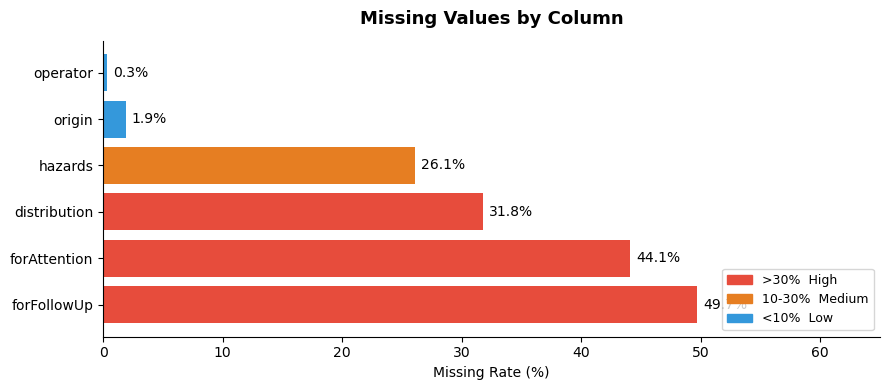

In [ ]:
import matplotlib.patches as mpatches
from collections import Counter

# rasff_clean is already in memory from Section 2.
# If running this section independently, uncomment the line below:
rasff_clean = pd.read_csv(DATA_DIR / "rasff_clean.csv") 

miss_count = rasff_clean.isnull().sum()
miss_pct   = (miss_count / len(rasff_clean) * 100).round(1)
summary = pd.DataFrame({
    'Missing Count': miss_count,
    'Missing %': miss_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('=== Missing Value Summary ===')
print(summary.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if p > 30 else '#e67e22' if p > 10 else '#3498db'
          for p in summary['Missing %']]
bars = ax.barh(summary.index, summary['Missing %'], color=colors, edgecolor='none')
for bar, pct in zip(bars, summary['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10)
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 65)
patches = [
    mpatches.Patch(color='#e74c3c', label='>30%  High'),
    mpatches.Patch(color='#e67e22', label='10-30%  Medium'),
    mpatches.Patch(color='#3498db', label='<10%  Low'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


### 3.2 `hazards` Column — MNAR Diagnosis & Feature Design

**Missingness mechanism: MNAR (Missing Not At Random)**

The 26.1% missingness in `hazards` is not random noise.  
Serious incidents have their hazard field filled in at much higher rates than low-risk or undecided cases,  
meaning that **the fact of missingness is itself a signal of risk level**.  
→ A binary **missing indicator must be preserved as a feature**.

---

### Two Distinct Information Sources → Four Features

A critical distinction: the four hazard-related features derive from **two different source columns**.
This matters for feature engineering and model interpretation.

#### Source A — `hazards` column (structured RASFF text, 26.1% missing)

| Feature | Example | Unique values | Method |
|---------|---------|---------------|--------|
| `hazard_tag` | `pesticide residues` | ~20 | Extract `{}` tag from `hazards` |
| `hazard_substance` | `chlorpyrifos` | 1,013 | Parse primary substance name from `hazards` |
| `hazards_missing` | 0 / 1 | 2 | Binary MNAR indicator — 1 when `hazards` is empty |

#### Source B — `subject` column (free-text notification title, 0% missing)

| Feature | Example | Unique values | Method |
|---------|---------|---------------|--------|
| `Hazard_Type` | `Chemical/Contaminants` | 9 | GPT-4o-mini classifies `subject` text into 9 classes (Section 4) |

> **Why `Hazard_Type` is NOT a decomposition of `hazards`:**  
> `Hazard_Type` is derived from `subject`, not from `hazards`.  
> This is confirmed by: (a) `Hazard_Type` is assigned even for the 7,830 rows where `hazards` is missing;  
> (b) their distributions differ sharply — when `hazards` is present, Chemical dominates (35.8%);  
> when `hazards` is missing, Others dominates (37.9%);  
> (c) the LLM prompt in Section 4 reads only the `subject` field, not `hazards`.  
> `Hazard_Type` provides **full-coverage coarse signal from subject**;  
> `hazard_tag` and `hazard_substance` provide **fine-grained signal from hazards where available**.

#### Information Loss Note

`hazards` contains structured RASFF internal tags in `{category}` format.  
Collapsing everything into the 9 LLM `Hazard_Type` categories would lose significant granularity:
- `Chemical/Contaminants` alone compresses 1,680 unique hazard strings  
- Mid-level tags like `pesticide residues` (10,178 cases) and `heavy metals` (1,150 cases) would be lost

This is why `hazard_tag` and `hazard_substance` are extracted directly from `hazards`
as independent features alongside `Hazard_Type`.



hazards missing rate by risk_decision (MNAR evidence):
risk_decision
serious                16.2
potentially serious    21.4
undecided              37.2
not serious            39.9
no risk                42.3
potential risk         46.9


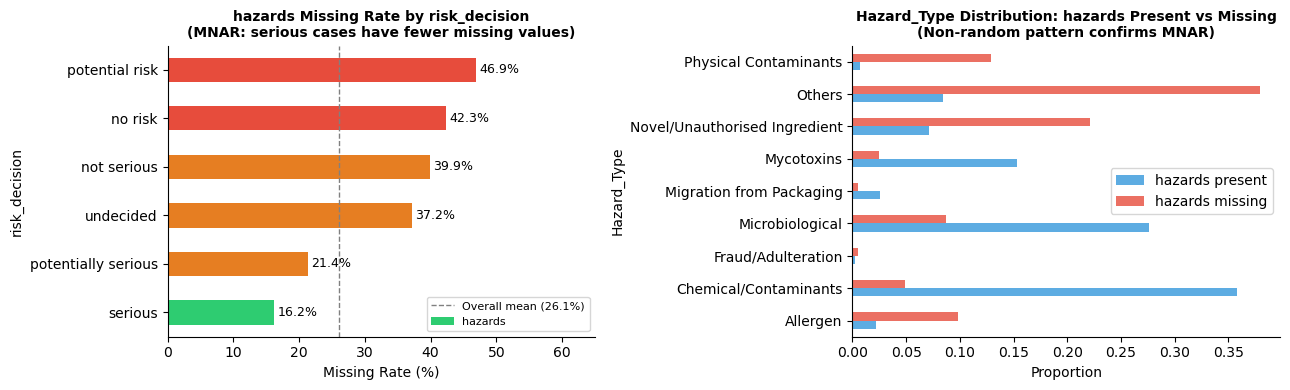

In [ ]:
# ── Step 1: Load data including Hazard_Type --> rasff_classified.csv ──────────────────────
# Hazard_Type was generated by the LLM in Section 4 (prior run).
# This avoids any dependency on re-running the LLM.

rasff_clean = pd.read_csv(DATA_DIR / "rasff_classified.csv") 

# ── Step 2: MNAR evidence — hazards missing rate by risk_decision ─────────────
mnar_stats = (
    rasff_clean.groupby('risk_decision')['hazards']
    .apply(lambda x: x.isnull().mean() * 100)
    .sort_values(ascending=True)
    .round(1)
)
print('\nhazards missing rate by risk_decision (MNAR evidence):')
print(mnar_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: MNAR bar chart
ax = axes[0]
colors = ['#2ecc71' if v < 20 else '#e67e22' if v < 40 else '#e74c3c' for v in mnar_stats.values]
mnar_stats.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
for i, v in enumerate(mnar_stats.values):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
ax.set_title('hazards Missing Rate by risk_decision\n(MNAR: serious cases have fewer missing values)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Missing Rate (%)')
ax.set_xlim(0, 65)
ax.spines[['top','right']].set_visible(False)
ax.axvline(x=26.1, color='gray', linestyle='--', linewidth=1, label='Overall mean (26.1%)')
ax.legend(fontsize=8)

# Right: Hazard_Type distribution — hazards present vs missing
ax2 = axes[1]
ht_present = rasff_clean[rasff_clean['hazards'].notna()]['Hazard_Type'].value_counts(normalize=True)
ht_missing  = rasff_clean[rasff_clean['hazards'].isnull()]['Hazard_Type'].value_counts(normalize=True)
compare = pd.DataFrame({'hazards present': ht_present, 'hazards missing': ht_missing}).fillna(0)
compare.plot(kind='barh', ax=ax2, color=['#3498db','#e74c3c'], alpha=0.8, edgecolor='none')
ax2.set_title('Hazard_Type Distribution: hazards Present vs Missing\n(Non-random pattern confirms MNAR)',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('Proportion')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()



#### 📌 Interpretation: What the Chart Reveals About MNAR

The right-hand chart shows the **composition** of each group — not per-type missing rates.  
Each bar represents a Hazard_Type's **share within** the `hazards present` group (blue)  
versus its share within the `hazards missing` group (red).  
A large red bar with a small blue bar signals that this Hazard_Type is **disproportionately  
over-represented among rows where `hazards` was never recorded**.

**Per-type missing rates (actual counts):**

| Hazard_Type | Total | hazards filled | Missing rate | Reason |
|-------------|-------|----------------|--------------|--------|
| Chemical/Contaminants | 8,309 | 7,924 | **4.6%** | Substance name always identifiable (pesticide, heavy metal) |
| Mycotoxins | 3,595 | 3,404 | **5.3%** | Toxin name (Aflatoxin B1, Ochratoxin A) always recorded |
| Microbiological | 6,800 | 6,115 | **10.1%** | Pathogen name usually specified |
| Allergen | 1,260 | 491 | **61.0%** | Labelling omission cases — no specific substance to record |
| Others | 4,844 | 1,876 | **61.3%** | Administrative/procedural — no technical hazard present |
| Physical Contaminants | 1,162 | 149 | **87.2%** | Reported as "foreign body found" without substance identification |

**Key insight — missingness encodes hazard type:**

The missing pattern is not random noise. It reflects a fundamental difference in **how hazards are reported**:

- **Low missing rate** (Chemical, Mycotoxins, Microbiological): these hazards involve a  
  chemically or biologically specific agent. The responsible officer always has a substance  
  name to fill in (e.g. `chlorpyrifos`, `Aflatoxin B1`, `Salmonella enteritidis`).

- **High missing rate** (Allergen, Others, Physical Contaminants): these hazards are often  
  characterised by **what is absent or misidentified**, not by the presence of a named substance.  
  An allergen notification for an unlabelled ingredient, a foreign body notification with no  
  identified material, or a purely procedural notification (missing certificate) — none of  
  these naturally produce a `hazards` field entry.

**Implication for modelling:**  
The `hazards_missing` binary flag is not a placeholder for "unknown data" — it is a  
**substantively informative feature** that captures a meaningful distinction in notification type.  
Models should retain this flag as an independent predictor alongside `Hazard_Type` and `hazard_tag`.

In [16]:
# ── Step 3: 2-layer feature extraction ───────────────────────────────────────
print('\n--- 2-Layer Feature Extraction ---')

def extract_primary_tag(h):
    """Layer 1: first RASFF internal {category} tag."""
    if pd.isnull(h): return 'unknown'
    tags = re.findall(r'\{([^}]+)\}', str(h))
    return tags[0].strip() if tags else 'unknown'

def extract_primary_substance(h):
    """Layer 2: primary substance name, cleaned."""
    if pd.isnull(h): return 'unknown'
    parts = str(h).split(',')
    m = re.match(r'^(.+?)\s+-\s+\{', parts[0].strip())
    if m:
        s = m.group(1).strip().lower()
        s = re.sub(r'\s+(unauthorised substance|high level|migration|too high content'
                   r'|illegal trade.*|susp.*)', '', s).strip()
        return s
    return parts[0].strip().lower()[:80] if parts[0].strip() else 'unknown'

rasff_clean['hazard_tag']       = rasff_clean['hazards'].apply(extract_primary_tag)
rasff_clean['hazard_substance'] = rasff_clean['hazards'].apply(extract_primary_substance)
rasff_clean['hazards_missing']  = rasff_clean['hazards'].isnull().astype(int)

print(f'hazard_tag       unique values : {rasff_clean["hazard_tag"].nunique()}')
print(f'hazard_substance unique values : {rasff_clean["hazard_substance"].nunique()}')
print(f'hazards_missing  (1=missing)   : {rasff_clean["hazards_missing"].sum():,} rows')
print()
print('hazard_tag distribution (Top 15):')
print(rasff_clean['hazard_tag'].value_counts().head(15).to_string())
print()
print('--- 2-Layer Sample (rows with hazards present) ---')
sample_cols = ['subject', 'hazards', 'hazard_tag', 'hazard_substance', 'hazards_missing']
print(rasff_clean[rasff_clean['hazards'].notna()][sample_cols].head(5).to_string(index=False))



--- 2-Layer Feature Extraction ---
hazard_tag       unique values : 30
hazard_substance unique values : 1017
hazards_missing  (1=missing)   : 7,830 rows

hazard_tag distribution (Top 15):
hazard_tag
unknown                           7855
pathogenic micro-organisms        6080
pesticide residues                5996
mycotoxins                        3461
heavy metals                      1045
composition                        806
migration                          624
food additives and flavourings     560
allergens                          480
natural toxins (other)             449
environmental pollutants           407
biological contaminants            362
novel food                         294
industrial contaminants            286
non-pathogenic micro-organisms     273

--- 2-Layer Sample (rows with hazards present) ---
                                                                  subject                                                                      hazards             

### 3.3 `origin` Column — MAR, Fill with `'Unknown'`

**Missingness mechanism: MAR (Missing at Random)**
- Missing rate: 1.9% (577 rows) — low
- No meaningful shift in `risk_decision` distribution between origin-missing and origin-present rows
- Interpretation: simply cases where origin country was not recorded

**Treatment:** Fill with `'Unknown'` as a distinct category. No separate missing indicator needed.  
*(Saar-Tsechansky & Provost 2007: for tree-based models at <5% missingness,  
simple imputation and sophisticated methods yield negligible performance differences.)*

In [17]:
# Compare risk_decision distribution: origin missing vs present
orig_miss  = rasff_clean[rasff_clean['origin'].isnull()]['risk_decision'].value_counts(normalize=True).round(3)
orig_exist = rasff_clean[rasff_clean['origin'].notna()]['risk_decision'].value_counts(normalize=True).round(3)
compare_origin = pd.DataFrame({'origin missing': orig_miss, 'origin present': orig_exist}).fillna(0)
print('risk_decision distribution by origin missingness (confirming no systematic bias):')
print(compare_origin.round(3).to_string())

# Fill missing origin
rasff_clean['origin'] = rasff_clean['origin'].fillna('Unknown')
print(f"\norigin fill complete: {rasff_clean['origin'].isnull().sum()} remaining")
print(f"'Unknown' proportion: {(rasff_clean['origin']=='Unknown').mean()*100:.1f}%")

risk_decision distribution by origin missingness (confirming no systematic bias):
                     origin missing  origin present
risk_decision                                      
no risk                       0.019           0.014
not serious                   0.198           0.147
potential risk                0.081           0.112
potentially serious           0.057           0.099
serious                       0.477           0.529
undecided                     0.168           0.099

origin fill complete: 0 remaining
'Unknown' proportion: 1.9%


### 3.4 Post-Decision Variables — Exclude from Predictive Model

#### `distribution`, `forAttention`, `forFollowUp` — Structurally Missing

These three columns contain **structurally absent data due to domain logic**, not data entry gaps:
- `border rejection` cases have a `distribution` missing rate of **76.9%**  
  → No distribution data exists because the product never entered the EU market
- All three are populated during post-incident response, not at notification submission
- **Not knowable at prediction time → Data Leakage risk**

#### `classification` — ⚠️ Post-Decision Variable

**RASFF process flow:**
1. Notification submitted (`category`, `origin`, `hazards`, `subject` are inputs)
2. **Risk assessed → `risk_decision` determined**
3. **Based on risk decision → `classification` type selected** (alert / border rejection / information)

**Data evidence:**
- Among `alert notification` rows, `risk_decision = 'serious'`: **86.9%** → alert is the *result*, not the cause
- Among `information for follow-up` rows, `not serious + potential risk`: **65.3%**
- Chi-squared test: Cramér's V = **0.524** (strong association)

**Conclusion: `classification` is a consequence of `risk_decision`, not a predictor.**  
Using it as a feature constitutes Data Leakage.

> **Two model scenarios will be trained in NB2:**
> - **Scenario A (Strict):** `classification` excluded — operationally deployable model
> - **Scenario B (Relaxed):** `classification` included — performance ceiling & post-hoc analysis

Chi2 = 11333.1,  p = 0.00e+00,  Cramer's V = 0.524
-> Strong association between classification and risk_decision (V > 0.5)

alert notification        -> serious risk:           86.9%
information for follow-up -> not serious/potential:  65.3%
-> risk_decision is determined first; classification is chosen as a result


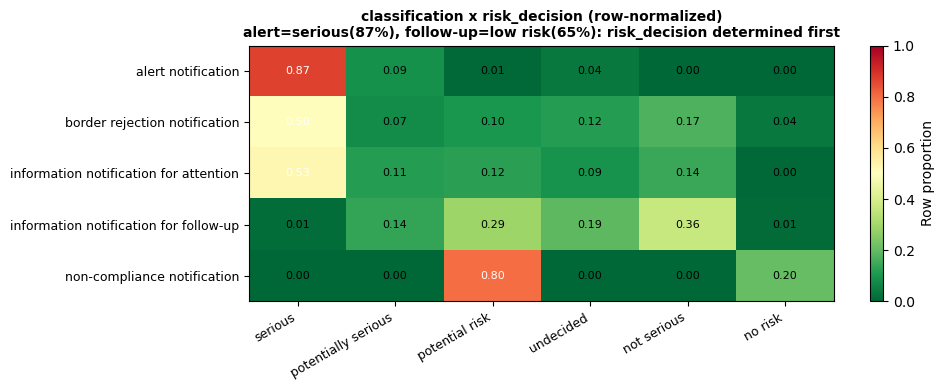


--- Structural Missingness: border rejection cases ---
                                        distribution  forAttention  forFollowUp
classification                                                                 
alert notification                               4.6          33.9          5.0
border rejection notification                   76.9          72.0         90.3
information notification for attention          20.1          20.9         79.9
information notification for follow-up          13.3          43.0         12.2
non-compliance notification                     20.0          20.0         60.0


In [18]:
from scipy.stats import chi2_contingency

# classification × risk_decision relationship
ct = pd.crosstab(rasff_clean['classification'], rasff_clean['risk_decision'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

chi2, p, dof, _ = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (chi2 + len(rasff_clean)))
print(f"Chi2 = {chi2:.1f},  p = {p:.2e},  Cramer's V = {cramers_v:.3f}")
print('-> Strong association between classification and risk_decision (V > 0.5)')

# Directional evidence
alert_serious = (
    len(rasff_clean[(rasff_clean['classification']=='alert notification') &
                    (rasff_clean['risk_decision']=='serious')]) /
    len(rasff_clean[rasff_clean['classification']=='alert notification'])
)
followup_low = (
    len(rasff_clean[(rasff_clean['classification']=='information notification for follow-up') &
                    (rasff_clean['risk_decision'].isin(['not serious','potential risk']))]) /
    len(rasff_clean[rasff_clean['classification']=='information notification for follow-up'])
)
print(f'\nalert notification        -> serious risk:           {alert_serious*100:.1f}%')
print(f'information for follow-up -> not serious/potential:  {followup_low*100:.1f}%')
print('-> risk_decision is determined first; classification is chosen as a result')

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
risk_order = ['serious','potentially serious','potential risk','undecided','not serious','no risk']
ct_plot = ct_norm.reindex(columns=risk_order, fill_value=0)
im = ax.imshow(ct_plot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Row proportion')
ax.set_xticks(range(len(risk_order)))
ax.set_xticklabels(risk_order, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(ct_plot)))
ax.set_yticklabels(ct_plot.index, fontsize=9)
for i in range(len(ct_plot)):
    for j in range(len(risk_order)):
        val = ct_plot.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if val > 0.5 else 'black')
ax.set_title(
    'classification x risk_decision (row-normalized)\n'
    'alert=serious(87%), follow-up=low risk(65%): risk_decision determined first',
    fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Structural missingness for post-decision columns
print('\n--- Structural Missingness: border rejection cases ---')
struct_miss = rasff_clean.groupby('classification')[['distribution','forAttention','forFollowUp']].apply(
    lambda x: x.isnull().mean() * 100
).round(1)
print(struct_miss.to_string())

### 3.5 `operator` Column — MCAR, Fill with `'Unknown'`

Missing rate: 0.34% (102 rows). Classified as MCAR. Fill with `'Unknown'`.  
Low utility as a model feature (5,207 unique values — too sparse for direct encoding),  
but usable in post-hoc analysis notebooks.

In [19]:
rasff_clean['operator'] = rasff_clean['operator'].fillna('Unknown')
print(f"operator fill complete: {rasff_clean['operator'].isnull().sum()} remaining")

operator fill complete: 0 remaining


### 3.6 Feature Validity Summary

| Column | Missing % | Mechanism | Post-decision? | Use in ML | Treatment |
|--------|-----------|-----------|----------------|-----------|----------|
| `category` | 0% | — | No | ✅ Feature | — |
| `type` | 0% | — | No | ✅ Feature | — |
| `subject` | 0% | — | No | ✅ Feature (text) | — |
| `notifying_country` | 0% | — | No | ✅ Feature | — |
| `origin` | 1.9% | MAR | No | ✅ Feature | Fill `'Unknown'` |
| `Hazard_Type` | 0% | — | No | ✅ Layer 1 | LLM 9-class (Section 4) |
| `hazard_tag` | 0% | — | No | ✅ Layer 2 | Extract `{}` tags |
| `hazard_substance` | — | — | No | ✅ Layer 3 | Parse substance name |
| `hazards_missing` | — | MNAR indicator | No | ✅ Feature | Binary flag |
| `operator` | 0.34% | MCAR | No | △ Low priority | Fill `'Unknown'` |
| `classification` | 0% | — | ⚠️ Yes | Scenario B only | Separate model version |
| `distribution` | 31.8% | Structural | ⚠️ Yes | ❌ Excluded | — |
| `forAttention` | 44.1% | Structural | ⚠️ Yes | ❌ Excluded | — |
| `forFollowUp` | 49.7% | Structural | ⚠️ Yes | ❌ Excluded | — |

> **NB2 Modeling Instructions:**
> - **Scenario A (Strict / Operational):** Exclude `classification` — predict risk at submission time
> - **Scenario B (Relaxed / Upper-bound):** Include `classification` — performance ceiling & post-hoc use

In [ ]:
# Final missing value check after Section 3 treatments
print('=== Missing Values After Section 3 Treatment ===')
remaining = rasff_clean.isnull().sum()
target_cols = ['hazards','origin','operator']
print(remaining[target_cols].to_string())

print('\nNew feature columns added:')
new_cols = ['hazard_tag', 'hazard_substance', 'hazards_missing']
for c in new_cols:
    print(f'  {c:25s}: {rasff_clean[c].nunique()} unique values')

print(f'\nFinal shape: {rasff_clean.shape}')

# Save updated clean file
rasff_clean.to_csv(DATA_DIR / "rasff_clean2.csv", index=False) 
print('\nSaved: rasff_clean2.csv (updated with Section 3 features)')

=== Missing Values After Section 3 Treatment ===
hazards     7830
origin         0
operator       0

New feature columns added:
  hazard_tag               : 30 unique values
  hazard_substance         : 1017 unique values
  hazards_missing          : 2 unique values

Final shape: (29984, 20)

Saved: rasff_clean2.csv (updated with Section 3 features)


---
## 4. LLM-Based Hazard Classification (GPT-4o-mini)

This section classifies each notification's `subject` line into one of **9 hazard types**  
using GPT-4o-mini, producing the `Hazard_Type` column saved in `rasff_classified.csv`.

**Normal workflow:** If `rasff_classified.csv` already exists, Section 3 joins `Hazard_Type`  
from it automatically. **You do not need to run this section again.**

**Re-run only when:** adding new data that has not yet been classified.

| Hazard Type | Examples |
|-------------|----------|
| Microbiological | Salmonella, Listeria, E. coli |
| Chemical/Contaminants | Lead, pesticides, titanium dioxide |
| Mycotoxins | Aflatoxin B1, Ochratoxin A |
| Allergen | Undeclared milk, peanuts |
| Physical Contaminants | Glass, metal fragments |
| Migration from Packaging | BPA, primary aromatic amines |
| Fraud/Adulteration | Mislabelled origin, adulterated oils |
| Novel/Unauthorised Ingredient | Unapproved novel food |
| Others | Administrative/procedural only |

> ⚠️ Requires `OPENAI_API_KEY`.

In [ ]:
# Uncomment and run only when re-running LLM classification:
# !pip install nest_asyncio


In [14]:
"""
RASFF Hazard Classification - Optimized Version
================================================
Key improvements:
1. Fully async parallel processing via asyncio + aiohttp (up to ~10x speed boost)
2. Separated system/user roles for cacheable prompt structure (token savings)
3. Optimized batch size (50 -> 100)
4. Exponential backoff + jitter for robust retry logic
5. SQLite caching to skip duplicate API calls on re-runs
6. Progress persistence (resume after interruption)
"""

import asyncio
import aiohttp
import json
import time
import random
import sqlite3
import hashlib
import os
import pandas as pd
from tqdm.asyncio import tqdm as async_tqdm
from tqdm import tqdm
from typing import Optional


# ─────────────────────────────────────────────
# Configuration (adjust to your environment)
# ─────────────────────────────────────────────
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
MODEL = "gpt-4o-mini"
MAX_CONCURRENT_REQUESTS = 20   # Concurrent requests (adjust by Tier: Tier1=5, Tier2=20, Tier3=50)
BATCH_SIZE = 100               # Subjects per batch (maximized within token limits)
MAX_RETRIES = 4
CACHE_DB = "rasff_cache.sqlite" # SQLite cache file path

CATEGORIES = [
    "Microbiological",
    "Chemical/Contaminants",
    "Mycotoxins",
    "Allergen",
    "Physical Contaminants",
    "Migration from Packaging",
    "Fraud/Adulteration",
    "Novel/Unauthorised Ingredient",
    "Others"
]

# ─────────────────────────────────────────────
# System prompt (static - eligible for OpenAI prompt caching)
# Separating this into the system role enables ~50% token cost
# reduction via OpenAI's prompt caching on repeated requests
# ─────────────────────────────────────────────
SYSTEM_PROMPT = """You are a specialized food safety expert classifying RASFF alert subject lines into exactly ONE hazard category.

STRICT RULES:
1. Classify by TECHNICAL HAZARD TYPE (bacteria, metal, pesticide) NOT regulatory status.
2. For multi-language subjects (separated by // or ///), use the English text.
3. Return ONLY a numbered list with category names. No quotes, no extra text.
4. Novel/Unauthorised: ONLY for substances unauthorized for specific food use.
5. Others: ONLY for purely administrative/procedural issues with no contaminant.

CATEGORIES:
1. Microbiological - bacteria, viruses, parasites, fungi (Salmonella, Listeria, E. coli)
2. Chemical/Contaminants - heavy metals, pesticides, industrial contaminants (lead, oxamyl, dioxins)
3. Mycotoxins - mold toxins in grains/nuts/dried fruit (Aflatoxin, Ochratoxin)
4. Allergen - undeclared allergenic ingredients (milk, soy, peanut, CASEINE)
5. Physical Contaminants - foreign objects (glass, metal, plastic, stone, bone)
6. Migration from Packaging - chemicals from packaging (PAA, Bisphenol, migration)
7. Fraud/Adulteration - intentional deception (adulterated, mismatch, mislabelled origin)
8. Novel/Unauthorised Ingredient - unapproved novel food ingredients, unauthorized botanicals
9. Others - no technical hazard (e.g., absence of official certificates only)"""

# ─────────────────────────────────────────────
# SQLite cache: prevents re-classifying duplicate subjects
# Any duplicate subjects among 30,000 rows will skip the API call entirely
# ─────────────────────────────────────────────
class ClassificationCache:
    def __init__(self, db_path: str):
        self.conn = sqlite3.connect(db_path, check_same_thread=False)
        self.conn.execute("""
            CREATE TABLE IF NOT EXISTS cache (
                hash TEXT PRIMARY KEY,
                subject TEXT,
                category TEXT,
                model TEXT,
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
            )
        """)
        self.conn.commit()

    def _hash(self, subject: str) -> str:
        return hashlib.md5(subject.strip().lower().encode()).hexdigest()

    def get(self, subject: str) -> Optional[str]:
        h = self._hash(subject)
        row = self.conn.execute(
            "SELECT category FROM cache WHERE hash=? AND model=?", (h, MODEL)
        ).fetchone()
        return row[0] if row else None

    def set_many(self, pairs: list[tuple[str, str]]):
        """Bulk insert [(subject, category), ...] into cache"""
        rows = [(self._hash(s), s, c, MODEL) for s, c in pairs]
        self.conn.executemany(
            "INSERT OR REPLACE INTO cache (hash, subject, category, model) VALUES (?,?,?,?)",
            rows
        )
        self.conn.commit()

    def close(self):
        self.conn.close()


# ─────────────────────────────────────────────
# Async batch classification function
# ─────────────────────────────────────────────
async def classify_batch_async(
    session: aiohttp.ClientSession,
    semaphore: asyncio.Semaphore,
    batch: list[str],
    batch_index: int
) -> list[str]:
    """
    Classifies a single batch asynchronously.
    Semaphore controls the number of concurrent requests.
    """
    formatted = "\n".join([f"{i+1}. {s}" for i, s in enumerate(batch)])
    user_content = f"Classify these {len(batch)} subjects:\n\n{formatted}"

    payload = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_content}
        ],
        "temperature": 0,
        "max_tokens": len(batch) * 12  # ~30 chars max per category name with buffer
    }

    for attempt in range(MAX_RETRIES):
        async with semaphore:
            try:
                async with session.post(
                    "https://api.openai.com/v1/chat/completions",
                    json=payload,
                    headers={
                        "Authorization": f"Bearer {OPENAI_API_KEY}",
                        "Content-Type": "application/json"
                    },
                    timeout=aiohttp.ClientTimeout(total=120)
                ) as resp:

                    # Rate limit: read wait time from response header
                    if resp.status == 429:
                        retry_after = float(resp.headers.get("Retry-After", 2 ** attempt))
                        print(f"\n[Batch {batch_index}] Rate limited. Waiting {retry_after:.1f}s...")
                        await asyncio.sleep(retry_after + random.uniform(0, 1))
                        continue

                    if resp.status != 200:
                        error_text = await resp.text()
                        print(f"\n[Batch {batch_index}] HTTP {resp.status}: {error_text[:200]}")
                        await asyncio.sleep(2 ** attempt + random.uniform(0, 1))
                        continue

                    data = await resp.json()
                    raw = data["choices"][0]["message"]["content"].strip()
                    return _parse_response(raw, len(batch))

            except asyncio.TimeoutError:
                print(f"\n[Batch {batch_index}] Timeout on attempt {attempt+1}")
                await asyncio.sleep(2 ** attempt)
            except Exception as e:
                print(f"\n[Batch {batch_index}] Error attempt {attempt+1}: {type(e).__name__}: {e}")
                await asyncio.sleep(2 ** attempt + random.uniform(0, 1))

    print(f"\n[Batch {batch_index}] All {MAX_RETRIES} attempts failed. Defaulting to 'Others'.")
    return ["Others"] * len(batch)


def _parse_response(raw: str, expected_count: int) -> list[str]:
    """Parse and validate LLM response"""
    results = []
    for line in raw.strip().split("\n"):
        line = line.strip()
        if not line:
            continue
        # Handle both "1. Microbiological" and bare "Microbiological" formats
        cat = line.split(". ", 1)[-1].strip() if ". " in line else line
        # Fuzzy match in case the LLM outputs a slightly different string
        matched = next(
            (c for c in CATEGORIES if c.lower() in cat.lower() or cat.lower() in c.lower()),
            "Others"
        )
        results.append(matched)
        if len(results) == expected_count:
            break

    # Pad with "Others" if the response was shorter than expected
    while len(results) < expected_count:
        results.append("Others")

    return results[:expected_count]


# ─────────────────────────────────────────────
# Main async classification pipeline
# ─────────────────────────────────────────────
async def classify_all_async(subjects: list[str]) -> list[str]:
    """Classify the full subject list in parallel (unordered / faster)"""

    # Step 1: Check cache -> only call API for uncached subjects
    cache = ClassificationCache(CACHE_DB)
    results = [None] * len(subjects)
    uncached_indices = []
    uncached_subjects = []

    cache_hits = 0
    for i, subj in enumerate(subjects):
        cached = cache.get(subj)
        if cached:
            results[i] = cached
            cache_hits += 1
        else:
            uncached_indices.append(i)
            uncached_subjects.append(subj)

    if cache_hits:
        print(f"✅ Cache hits: {cache_hits}/{len(subjects)} subjects skipped API call")

    if not uncached_subjects:
        cache.close()
        return results

    # Step 2: Build batches
    batches = [
        uncached_subjects[i:i+BATCH_SIZE]
        for i in range(0, len(uncached_subjects), BATCH_SIZE)
    ]
    print(f"📦 Total batches: {len(batches)} (batch size: {BATCH_SIZE}, concurrency: {MAX_CONCURRENT_REQUESTS})")

    # Step 3: Async parallel execution
    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    batch_results = []

    connector = aiohttp.TCPConnector(limit=MAX_CONCURRENT_REQUESTS + 5)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [
            classify_batch_async(session, semaphore, batch, idx)
            for idx, batch in enumerate(batches)
        ]
        # Progress bar via tqdm
        for coro in async_tqdm.as_completed(tasks, total=len(tasks), desc="🔍 Classifying batches"):
            result = await coro
            batch_results.append(result)

    # Step 4: Flatten results and map back to original indices
    flat_results = [cat for batch in batch_results for cat in batch]

    # NOTE: as_completed does not preserve order.
    # Use classify_all_async_ordered() below if ordering matters.
    # flat_results = [cat for batch in await asyncio.gather(*tasks) for cat in batch]

    for i, (orig_idx, cat) in enumerate(zip(uncached_indices, flat_results)):
        results[orig_idx] = cat

    # Step 5: Save new results to cache
    new_pairs = list(zip(uncached_subjects, flat_results))
    cache.set_many(new_pairs)
    cache.close()

    return results


# ─────────────────────────────────────────────
# Order-preserving version (uses gather instead of as_completed)
# Slightly slower but results are returned in input order
# ─────────────────────────────────────────────
async def classify_all_async_ordered(subjects: list[str]) -> list[str]:
    """Order-preserving version using asyncio.gather"""
    cache = ClassificationCache(CACHE_DB)
    results = [None] * len(subjects)
    uncached_indices = []
    uncached_subjects = []

    for i, subj in enumerate(subjects):
        cached = cache.get(subj)
        if cached:
            results[i] = cached
        else:
            uncached_indices.append(i)
            uncached_subjects.append(subj)

    if not uncached_subjects:
        cache.close()
        return results

    batches = [
        uncached_subjects[i:i+BATCH_SIZE]
        for i in range(0, len(uncached_subjects), BATCH_SIZE)
    ]

    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    connector = aiohttp.TCPConnector(limit=MAX_CONCURRENT_REQUESTS + 5)

    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [
            classify_batch_async(session, semaphore, batch, idx)
            for idx, batch in enumerate(batches)
        ]
        # gather returns results in the same order as input tasks
        with tqdm(total=len(batches), desc="🔍 Classifying (ordered)") as pbar:
            gathered = await asyncio.gather(*tasks)
            pbar.update(len(batches))

    flat_results = [cat for batch in gathered for cat in batch]

    for orig_idx, cat in zip(uncached_indices, flat_results):
        results[orig_idx] = cat

    cache.set_many(list(zip(uncached_subjects, flat_results)))
    cache.close()
    return results


# ─────────────────────────────────────────────
# DataFrame interface (drop-in replacement for original code)
# ─────────────────────────────────────────────
def classify_full_dataframe(
    df: pd.DataFrame,
    subject_column: str = 'subject',
    ordered: bool = True
) -> pd.DataFrame:
    """
    Drop-in replacement for the original classify_full_dataframe.
    Runs async processing internally.

    Args:
        df: Input DataFrame
        subject_column: Name of the column containing subject strings
        ordered: True = preserve row order (recommended), False = faster as_completed mode
    """
    subjects = df[subject_column].fillna("N/A - Missing Subject").astype(str).tolist()

    start = time.time()
    print(f"\n{'='*50}")
    print(f"📊 Starting classification of {len(subjects):,} subjects")
    print(f"   Model: {MODEL} | Batch size: {BATCH_SIZE} | Concurrency: {MAX_CONCURRENT_REQUESTS}")
    print(f"{'='*50}\n")

    # Run event loop (handles both script and Jupyter environments)
    try:
        loop = asyncio.get_event_loop()
        if loop.is_running():
            # Jupyter / IPython environment
            import nest_asyncio
            nest_asyncio.apply()
            results = loop.run_until_complete(
                classify_all_async_ordered(subjects) if ordered
                else classify_all_async(subjects)
            )
        else:
            results = loop.run_until_complete(
                classify_all_async_ordered(subjects) if ordered
                else classify_all_async(subjects)
            )
    except RuntimeError:
        results = asyncio.run(
            classify_all_async_ordered(subjects) if ordered
            else classify_all_async(subjects)
        )

    elapsed = time.time() - start
    df['Hazard_Type'] = results

    print(f"\n{'='*50}")
    print(f"✅ Done! Elapsed: {elapsed/60:.1f} min ({elapsed:.0f} sec)")
    print(f"   Throughput: {len(subjects)/elapsed:.0f} subjects/sec")
    print(f"\n📈 Classification distribution:")
    print(df['Hazard_Type'].value_counts().to_string())
    print(f"{'='*50}\n")

    return df


# ─────────────────────────────────────────────
# Async version for direct use in Jupyter Notebook
# ─────────────────────────────────────────────
async def classify_full_dataframe_async(
    df: pd.DataFrame,
    subject_column: str = 'subject'
) -> pd.DataFrame:
    """Awaitable version for use directly in Jupyter with 'await'"""
    subjects = df[subject_column].fillna("N/A - Missing Subject").astype(str).tolist()
    results = await classify_all_async_ordered(subjects)
    df['Hazard_Type'] = results
    return df


# ─────────────────────────────────────────────
# Example usage
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # Sample DataFrame for testing
    sample_data = {
        'subject': [
            "Salmonella in frozen chicken from Brazil",
            "Undeclared milk allergen in chocolate cookies",
            "Aflatoxin B1 in groundnuts from Egypt",
            "Glass fragments in tomato sauce",
            "Absence of health certificate // Fehlen des Gesundheitszeugnisses",
            "Mislabelled origin of honey - adulteration suspected",
            "Lead contamination in ceramic cookware migration",
            "Listeria monocytogenes in ready-to-eat smoked salmon",
            "Unauthorised novel food ingredient - CBD oil",
            "Pesticide residues (oxamyl) exceeding MRL in oranges"
        ]
    }
    df_test = pd.DataFrame(sample_data)

    # Run classification
    df_result = classify_full_dataframe(df_test)
    print("\nResult preview:")
    print(df_result[['subject', 'Hazard_Type']].to_string())


📊 Starting classification of 10 subjects
   Model: gpt-4o-mini | Batch size: 100 | Concurrency: 20



🔍 Classifying (ordered): 100%|██████████| 1/1 [00:03<00:00,  3.34s/it]


✅ Done! Elapsed: 0.1 min (3 sec)
   Throughput: 3 subjects/sec

📈 Classification distribution:
Hazard_Type
Microbiological                  2
Allergen                         1
Mycotoxins                       1
Physical Contaminants            1
Others                           1
Fraud/Adulteration               1
Migration from Packaging         1
Novel/Unauthorised Ingredient    1
Chemical/Contaminants            1


Result preview:
                                                             subject                    Hazard_Type
0                           Salmonella in frozen chicken from Brazil                Microbiological
1                      Undeclared milk allergen in chocolate cookies                       Allergen
2                              Aflatoxin B1 in groundnuts from Egypt                     Mycotoxins
3                                    Glass fragments in tomato sauce          Physical Contaminants
4  Absence of health certificate // Fehlen des Gesundheitsz

In [ ]:
# ── Run classification (uncomment only when generating Hazard_Type from scratch) ──
#
# rasff_to_classify = pd.read_csv('../data/processed/rasff_clean.csv')
# rasff_to_classify  = classify_full_dataframe(rasff_to_classify)
# rasff_to_classify.to_csv('../data/processed/rasff_classified.csv', index=False)
# print('Saved: rasff_classified.csv')


Hazard_Type
Chemical/Contaminants            8309
Microbiological                  6800
Others                           4844
Mycotoxins                       3595
Novel/Unauthorised Ingredient    3321
Allergen                         1260
Physical Contaminants            1162
Migration from Packaging          608
Fraud/Adulteration                 85


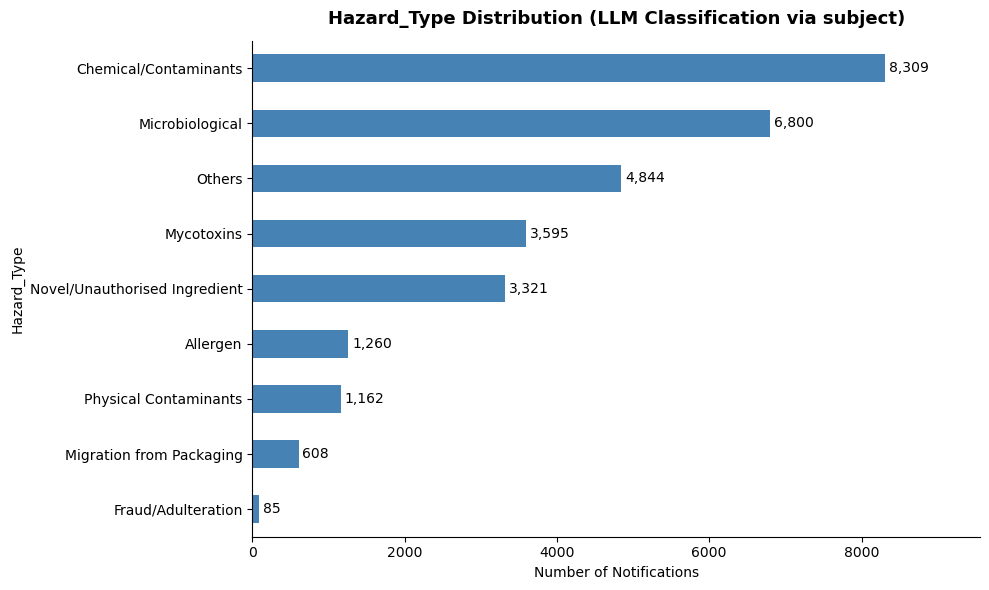

In [21]:
# Distribution of Hazard_Type across the full dataset
counts = rasff_clean['Hazard_Type'].value_counts()
print(counts.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
counts.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
for i, val in enumerate(counts.sort_values().values):
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=10)
ax.set_title('Hazard_Type Distribution (LLM Classification via subject)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Notifications')
ax.set_xlim(0, counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


---
## Pipeline Summary

| File | Contents | Rows |
|------|----------|------|
| `rasff_clean.csv` | Cleaned data + `hazard_tag` / `hazard_substance` / `hazards_missing` | ~30k |
| `rasff_classified.csv` | Above + `Hazard_Type` from LLM — canonical output file for NB2 | ~30k |

**Columns added in this notebook:**

| Column | Source | Added in | Description |
|--------|--------|----------|-------------|
| `year`, `month` | `date` | Section 2 | Extracted from `date` |
| `hazard_tag` | **`hazards`** | Section 3.2 | Primary RASFF internal `{category}` tag |
| `hazard_substance` | **`hazards`** | Section 3.2 | Primary substance name parsed from `hazards` |
| `hazards_missing` | **`hazards`** | Section 3.2 | Binary MNAR indicator — 1 if `hazards` was empty |
| `Hazard_Type` | **`subject`** | Section 3.2 (joined from Section 4) | GPT-4o-mini 9-class classification from `subject` text |

> ⚠️ `Hazard_Type` is derived from `subject`, not from `hazards`.  
> `hazard_tag` and `hazard_substance` are derived from `hazards`.  
> These four features come from two different source columns and carry independent information.
